## Imports

In [49]:
# from copyreg import pickle
import joblib
import pandas as pd
import numpy as np
# from pyexpat import model

# from matplotlib.pyplot import grid
# from pandas.core.groupby import grouper
# from scipy.sparse import data
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
# from sqlalchemy.dialects.mssql.information_schema import columns
# from webencodings import x_user_defined
import streamlit as st



In [2]:
disease_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\ml\data.csv")
print(disease_df.head())



   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

In [3]:
print(disease_df)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

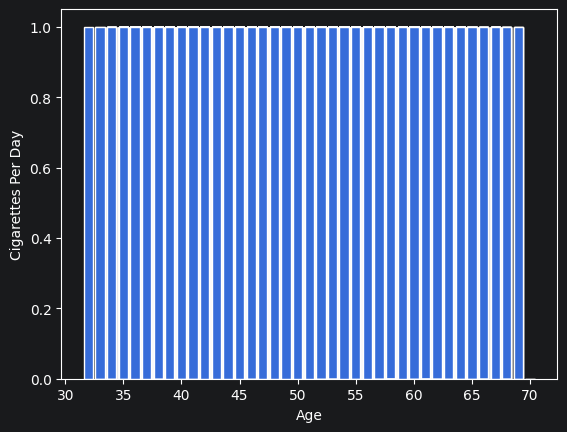

In [4]:
plt.bar(disease_df["age"],disease_df["currentSmoker"],
        edgecolor="white")
plt.xlabel("Age")
plt.ylabel("Cigarettes Per Day")
# plt.legend()
plt.show()


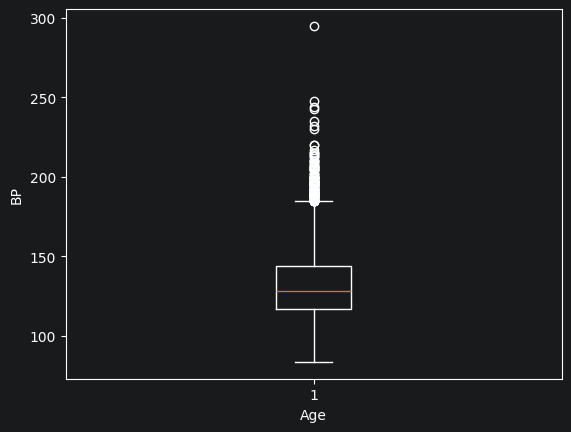

In [5]:
labels = disease_df["age"]
data = disease_df["sysBP"]
plt.boxplot(data)
plt.xlabel("Age")
plt.ylabel("BP")
# plt.legend()
plt.show()



In [6]:
disease_df.shape


(4240, 16)

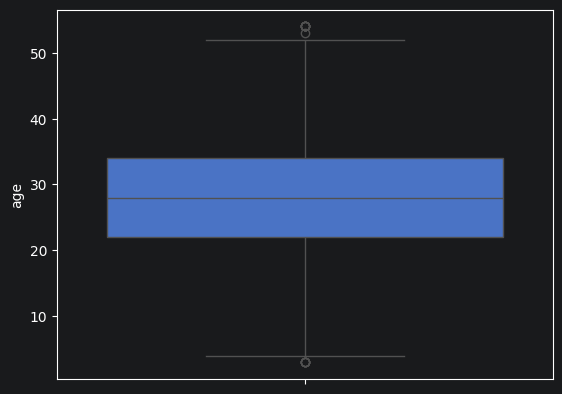

In [7]:
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
df=sns.load_dataset("titanic")
si= SimpleImputer(strategy="median")
df["age"]=si.fit_transform(df[["age"]])

import numpy as np
q1 = np.percentile(df["age"],25)
q3 = np.percentile(df["age"],75)
iqr = q3-q1
Min_range = q1-(1.5*iqr)
MAX_RANGE = q3+(1.5*iqr)
df=df[(df["age"]>=Min_range)&(df["age"]<=MAX_RANGE)]
sns.boxplot(y="age",data=df)
plt.show()

In [8]:
print(disease_df)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

In [9]:
disease_df.drop('education',axis=1,inplace=True)

In [10]:
disease_df.isnull().sum()




male                 0
age                  0
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [11]:
#fill missing values for binary features with the most frequent value(mode)
from sklearn.impute import SimpleImputer
bin_cols = ["male","currentSmoker","prevalentStroke","prevalentHyp","diabetes"]
imputer = SimpleImputer(strategy="most_frequent")
disease_df[bin_cols] = imputer.fit_transform(disease_df[bin_cols])


In [12]:
disease_df.isnull().sum()

male                 0
age                  0
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [13]:
from sklearn.impute import SimpleImputer
bin_cols = ["cigsPerDay","BPMeds","totChol","BMI","heartRate","glucose"]
imputer = SimpleImputer(strategy="median")
disease_df[bin_cols] = imputer.fit_transform(disease_df[bin_cols])

In [14]:
disease_df.isnull().sum()

male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [15]:
disease_df['TenYearCHD'].value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

In [16]:
from imblearn.over_sampling import RandomOverSampler

# Separate features and target
X = disease_df.drop('TenYearCHD', axis=1)
y = disease_df['TenYearCHD']
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)
disease_df_balance = X_resampled.copy()
disease_df_balance['TenYearCHD'] = y_resampled


In [17]:
disease_df_balance['TenYearCHD'].value_counts()

TenYearCHD
0    3596
1    3596
Name: count, dtype: int64

<BarContainer object of 4240 artists>

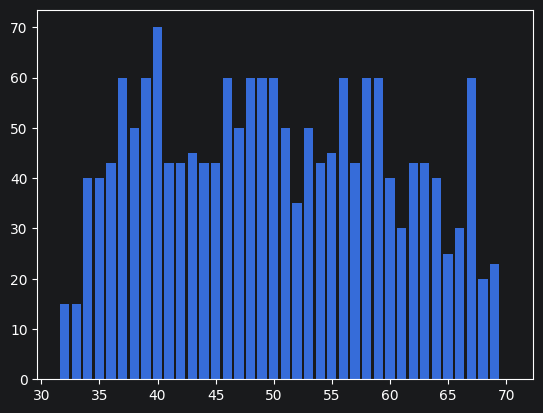

In [18]:
plt.bar(disease_df["age"],disease_df["cigsPerDay"])

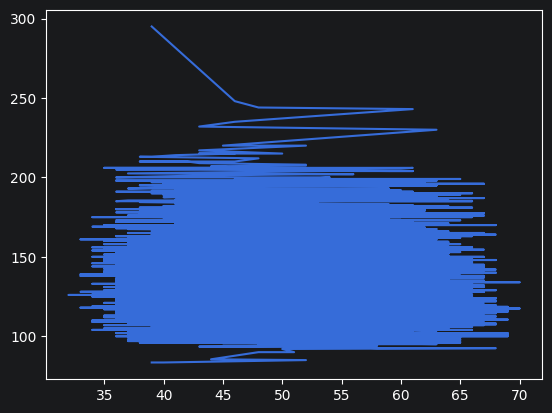

In [19]:
df = disease_df.sort_values(by=["sysBP"],ascending=False)
plt.plot(disease_df["age"],df["sysBP"])
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x=disease_df_balance.drop(columns=['TenYearCHD'])
y=disease_df_balance['TenYearCHD']
x = preprocessing.StandardScaler().fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print('train set',x_train.shape,y_train.shape)
print('test set',x_test.shape,y_test.shape)

train set (5753, 14) (5753,)
test set (1439, 14) (1439,)


In [21]:
print(y_test.value_counts())
print(y_train.value_counts())# Ten Year CHD Record of all the patients available in the dataset

TenYearCHD
0    745
1    694
Name: count, dtype: int64
TenYearCHD
1    2902
0    2851
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13624\222483282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD',data=disease_df,


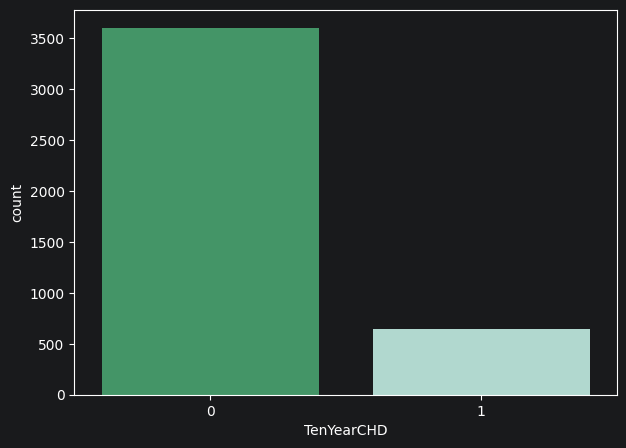

In [22]:
plt.figure(figsize=(7,5)),
sns.countplot(x='TenYearCHD',data=disease_df,
              palette="BuGn_r")
plt.show()

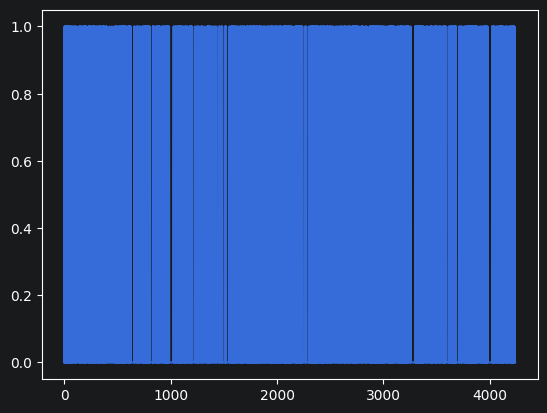

In [23]:
laste = disease_df['TenYearCHD'].plot()
plt.show(laste)

In [24]:
#fitting logistic regression model for heart disease prediction
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(x_train,y_train)
y_pred = logreg.predict(x_test)

In [25]:
from sklearn.metrics import accuracy_score
print('accuracy of the model is =',
      accuracy_score(y_test,y_pred))

accuracy of the model is = 0.6497567755385685


In [26]:
x_train

array([[ 1.06109554,  1.67858157,  0.98235804, ...,  0.59442505,
        -0.09681889,  4.13664723],
       [ 1.06109554, -0.05189174,  0.98235804, ...,  0.65095608,
        -0.34621769,  0.0725371 ],
       [-0.94242221,  0.17883803, -1.01795879, ...,  1.27279741,
         0.98390924,  0.0725371 ],
       ...,
       [ 1.06109554, -1.09017573,  0.98235804, ...,  0.66979976,
         0.81764338, -0.36852912],
       [-0.94242221,  1.21712202,  0.98235804, ...,  0.06915756,
        -0.01368596,  0.63962223],
       [-0.94242221, -1.89772994, -1.01795879, ..., -1.2852317 ,
         1.15017511, -0.14799601]], shape=(5753, 14))

the detail for confusion matrix is =
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       745
           1       0.63      0.65      0.64       694

    accuracy                           0.65      1439
   macro avg       0.65      0.65      0.65      1439
weighted avg       0.65      0.65      0.65      1439



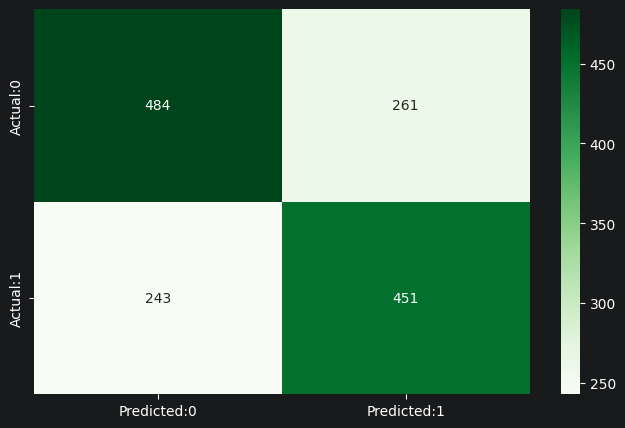

In [27]:
from  sklearn.metrics import confusion_matrix, classification_report
print('the detail for confusion matrix is =')
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
conf_matrix = pd.DataFrame(data= cm,
                           columns=['Predicted:0','Predicted:1'],
                           index =['Actual:0','Actual:1'])
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix,annot=True,fmt="d", cmap="Greens")
plt.show()

In [28]:
#intialze standardscaler
scaler = StandardScaler()
# fit scaler to training data and transform both training and testing data

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(x_train_scaled,y_train)
y_pred = rf_model.predict(x_test_scaled)


the detail for confusion matrix is =
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       745
           1       0.95      0.96      0.95       694

    accuracy                           0.95      1439
   macro avg       0.95      0.95      0.95      1439
weighted avg       0.95      0.95      0.95      1439



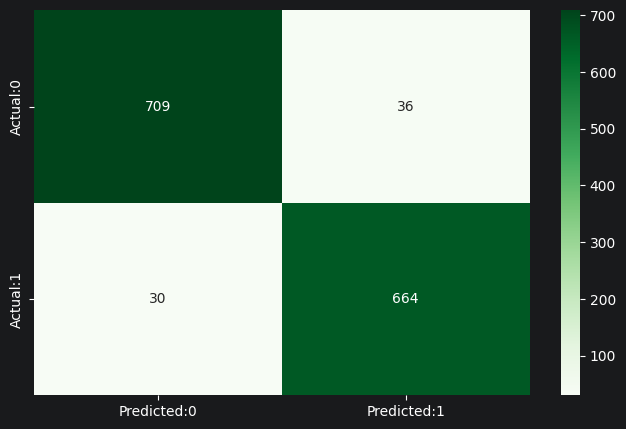

In [30]:
from  sklearn.metrics import confusion_matrix, classification_report
print('the detail for confusion matrix is =')
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
conf_matrix = pd.DataFrame(data= cm,
                           columns=['Predicted:0','Predicted:1'],
                           index =['Actual:0','Actual:1'])
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix,annot=True,fmt="d", cmap="Greens")
plt.show()

In [31]:
print(len(y_train))
print(len(y_test))
print(len(y_pred))

5753
1439
1439


In [32]:
from sklearn.metrics import accuracy_score
print('accuracy of the model is =',
      accuracy_score(y_test,y_pred))


accuracy of the model is = 0.9541348158443363


In [33]:
confusion_matrix(y_test,y_pred)

array([[709,  36],
       [ 30, 664]])

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       745
           1       0.95      0.96      0.95       694

    accuracy                           0.95      1439
   macro avg       0.95      0.95      0.95      1439
weighted avg       0.95      0.95      0.95      1439



In [35]:
from sklearn.metrics import accuracy_score
rf_model.score(x_train_scaled, y_train)


1.0

In [36]:
disease_df

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [37]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
disease_df["TenYearCHD"] = encoder.fit_transform(disease_df["TenYearCHD"])


In [38]:
disease_df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


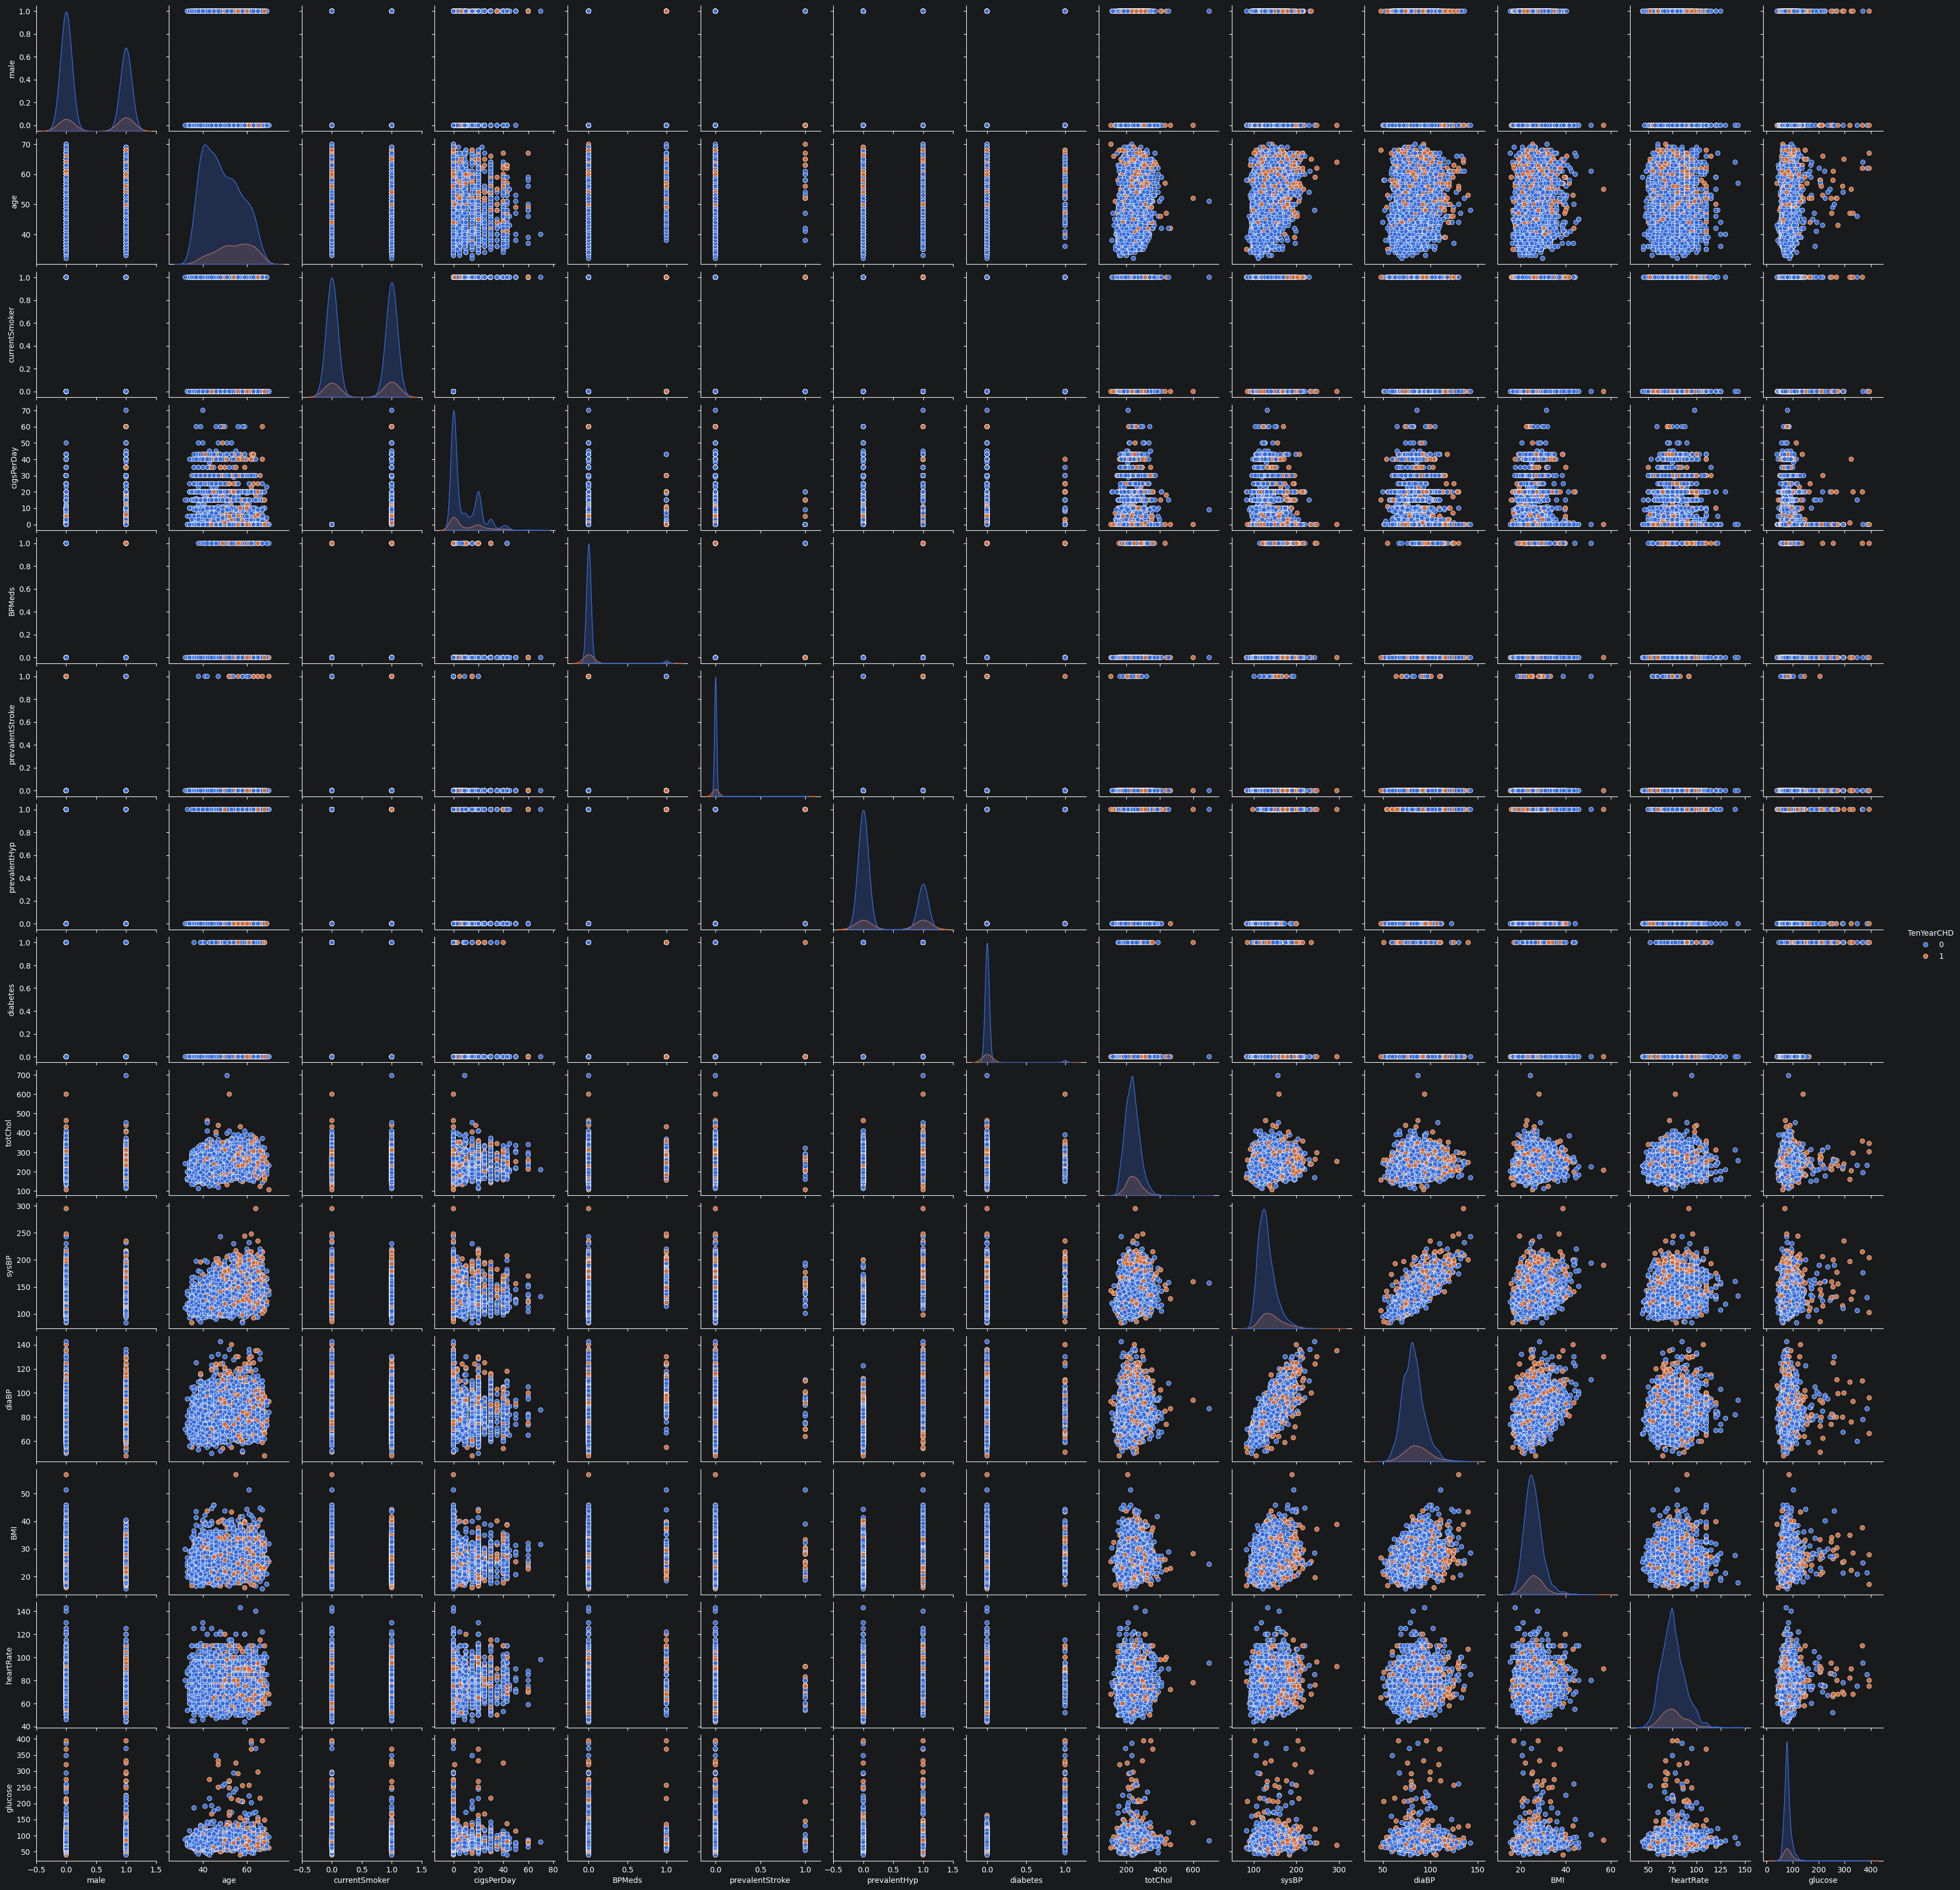

In [39]:
import seaborn as sns
sns.pairplot(disease_df,hue="TenYearCHD")

In [40]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()

In [41]:
estimators = [
    ('ls',clf1),('rf',clf2)
]

In [42]:
X = disease_df.drop("TenYearCHD", axis=1)
y = disease_df["TenYearCHD"]

In [43]:
from sklearn.model_selection import cross_val_score
import numpy as np


for estimator in estimators:
    x = cross_val_score(estimator[1], X, y, cv=10, scoring='accuracy')
    print(estimator[0], np.round(np.mean(x), 2))

C:\Users\LENOVO\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\LENOVO\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/p

ls 0.85
rf 0.85


In [44]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=estimators, voting='soft')
print(np.round(np.mean(x), 2))


0.85


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x=disease_df.drop(columns=['TenYearCHD'])
y=disease_df['TenYearCHD']
x = StandardScaler().fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print('train set',x_train.shape,y_train.shape)
print('test set',x_test.shape,y_test.shape)

train set (3392, 14) (3392,)
test set (848, 14) (848,)


In [46]:
from joblib import dump
# dump(rf_model,'rf_model.joblib')
# dump(voting,'voting_model.joblib')
# dump(logreg,'logistic_model')



In [47]:
from joblib import dump
dump(logreg,'logistic_model.joblib')

['logistic_model']